## Explore nested-EAGLE global forecasts

The **nested-Experimental Artificial Intelligence Global and Limited-area Ensemble (nested-EAGLE)** is an experimental machine-learning weather forecast system developed through a joint effort between NOAA Research Laboratories, the Earth Prediction Innovation Center (EPIC), and the National Weather Service (NWS). Trained with the European Centre for Medium-Range Weather Forecasts (ECMWF) and partner agencies Anemoi framework, it uses a combination of 0.25° Global Forecast System (GFS) data and 6-km High-Resolution Rapid Refresh (HRRR) data over CONUS.

This tutorial demonstrates how to discover nested-EAGLE global forecast items in the Microsoft Planetary Computer STAC catalog, stream a signed remote netCDF asset with obstore and obspec-utils, select surface variables and forecast times, create a map, and animate a forecast sequence with GeoGIF.

## Dataset at a glance

- **Coverage:** October 1, 2024 to present
- **Global grid:** 0.25-degree resolution; the 6 km CONUS nest is conservatively regridded onto this grid
- **Initialization:** Four cycles daily at 00, 06, 12, and 18 Z, typically available about six hours later
- **Forecast horizon:** 10 days (240 hours) at 6-hour intervals
- **Format:** One netCDF file per forecast, with 2D surface, 10 m, and 80 m fields plus 3D atmospheric fields on 12 pressure levels from 100 to 1000 hPa

The collection is provided free of charge on an unsupported, experimental basis. It should not be used for critical operational decisions.

**Producer:** NOAA EPIC  
**Host:** Microsoft Planetary Computer

**Citation:** The Earth Prediction Innovation Center (EPIC) and the NOAA AI for Numerical Weather Prediction (AI4NWP) Working Group. (2026). *The nested-EAGLE (Experimental AI Global and Limited-area Ensemble forecast system) v1.1.0*. Zenodo. [https://doi.org/10.5281/zenodo.19672026](https://doi.org/10.5281/zenodo.19672026)

Install the dependencies, then load the imports and variables used throughout the notebook. GeoGIF 0.3 requires Matplotlib 3.9 or earlier. Restart the kernel after the installation cell if it changes installed packages.

In [ ]:
%pip install pystac-client obstore obspec-utils geogif xarray "matplotlib<3.10" matplotlib-inline cartopy h5netcdf h5py dask

In [6]:
from datetime import datetime, timedelta, timezone

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geogif
import matplotlib.pyplot as plt
import numpy as np
import pystac_client
import xarray as xr
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure
from obspec_utils.readers import BlockStoreReader
from obstore.store import HTTPStore

# chose forecasts you wish to load
# code will filter stac item search to initializations between start and stop
init_start = "2025-01-31T18:00:00"
init_stop = "2025-02-02T18:00:00"

# chose forecast and the amount of lead time you wish to plot.
init_to_plot = datetime(2025, 1, 31, 18, tzinfo=timezone.utc)
# easy-to-edit lead times
forecast_start_lead = timedelta(hours=0)  # set to 0 to start with initial conditions
forecast_stop_lead = timedelta(hours=240)  # complete forecast horizon

variables_to_load = [
    "2m_temperature",
    "total_precipitation_6hr",
    "10m_meridional_wind",
]

Load STAC items from Planetary Computer

In [7]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    parameters={"sign": "true"},
)
matching_items = catalog.search(
    collections=["nested-eagle-global"],
    datetime=f"{init_start}Z/{init_stop}Z",
).item_collection()

print(len(matching_items))

49


Load a single forecast with obstore and obspec-utils. `HTTPStore` uses the signed asset URL returned by the STAC API, while `BlockStoreReader` provides the random-access file interface required by h5netcdf without downloading the entire file.

In [8]:
init_str = init_to_plot.strftime("%Y%m%d-%Hz")
forecast_start = (init_to_plot + forecast_start_lead).strftime("%Y-%m-%dT%H:%M:%S")
forecast_stop = (init_to_plot + forecast_stop_lead).strftime("%Y-%m-%dT%H:%M:%S")

item = next(
    (entry for entry in matching_items if entry.id.endswith(init_str)),
    None,
)

asset_href = item.assets["global"].href
store = HTTPStore.from_url(asset_href)

with BlockStoreReader(store, "") as remote_file, xr.open_dataset(
    remote_file,
    engine="h5netcdf",
    chunks={},
) as full_ds:
    ds = (
        full_ds[variables_to_load].sel(time=slice(forecast_start, forecast_stop)).load()
    )

ds

<xarray.Dataset> Size: 518MB
Dimensions:                  (time: 41, latitude: 719, longitude: 1440)
Coordinates:
  * time                     (time) datetime64[ns] 328B 2025-01-31T18:00:00 ....
  * latitude                 (latitude) float64 6kB 89.75 89.5 ... -89.5 -89.75
  * longitude                (longitude) float64 12kB -180.0 -179.8 ... 179.8
    nest_mask                (latitude, longitude) int64 8MB 0 0 0 0 ... 0 0 0 0
Data variables:
    2m_temperature           (time, latitude, longitude) float32 170MB 257.1 ...
    total_precipitation_6hr  (time, latitude, longitude) float32 170MB nan .....
    10m_meridional_wind      (time, latitude, longitude) float32 170MB -4.241...
Attributes:
    forecast_reference_time:  2025-01-31T18:00:00.000000000
    description:              Output from NOAA's Nested-EAGLE forecast model ...
    grid_projection:          Latitude-Longitude
    horizontal_resolution:    0.25 degree
    regrid:                   The 6km resolution data over the Contiguous Uni...
    version:                  1.0
    Conventions:              CF-1.8

Plot a variable from the forecast

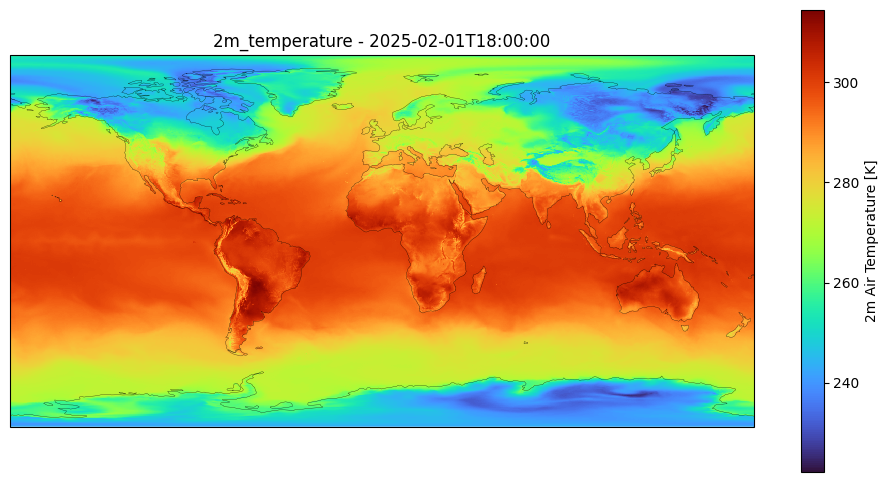

In [9]:
var_to_plot = "2m_temperature"  # can change to meridional wind or precipitation.
time_to_plot = "2025-02-01T18:00:00"  # can change to a different hour in your forecast.

field = (
    ds[var_to_plot]
    .sel(
        time=time_to_plot,
    )
    .squeeze()
)

fig, ax = plt.subplots(
    figsize=(12, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

field.plot.pcolormesh(
    ax=ax, x="longitude", y="latitude", transform=ccrs.PlateCarree(), cmap="turbo"
)

plt.title(f"{var_to_plot} - {time_to_plot}")

ax.coastlines(linewidth=0.2)
plt.show()

Create a Dask-backed GIF from the forecast with GeoGIF

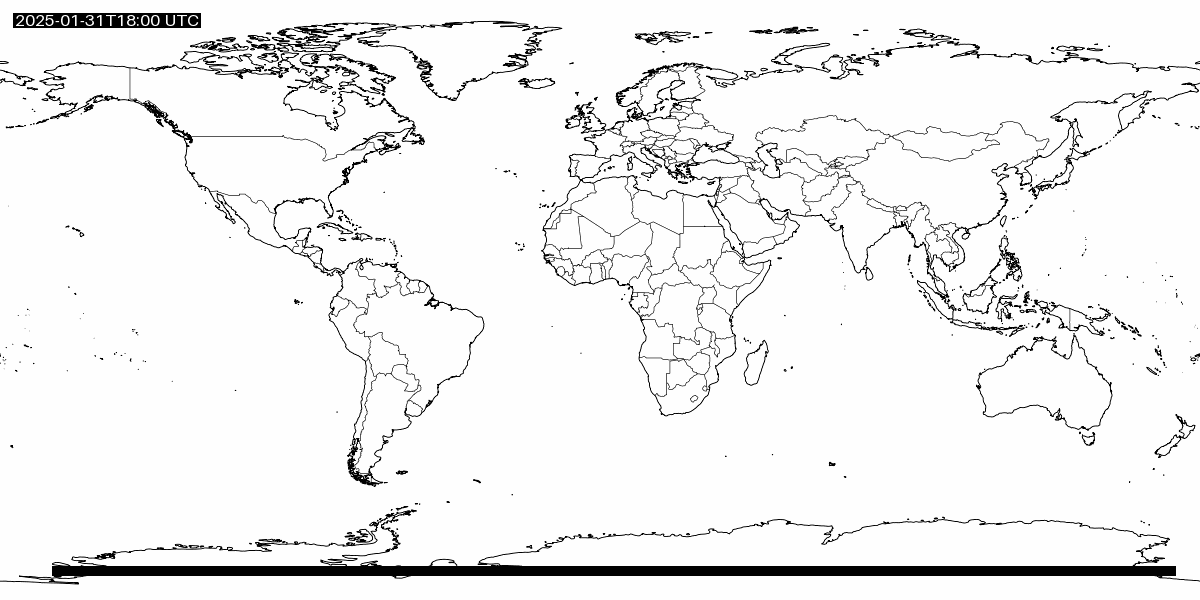

In [10]:
var_to_plot = "total_precipitation_6hr"

field = ds[var_to_plot]
gif_title = f"nested-EAGLE global forecast initialized {init_to_plot:%Y-%m-%d %HZ}"
scale_label = f"{field.attrs['long_name']} ({field.attrs['units']})"


def add_progress_bar(image, frame_index, frame_count):
    height, width, _ = image.shape
    margin = max(8, width // 50)
    bar_height = max(6, height // 60)
    y_start = height - margin - bar_height
    x_start, x_stop = margin, width - margin
    fill_stop = x_start + round((x_stop - x_start) * (frame_index + 1) / frame_count)
    bar_rows = slice(y_start, y_start + bar_height)
    image[bar_rows, slice(x_start, x_stop)] = (30, 30, 30)
    image[bar_rows, slice(x_start, fill_stop)] = (255, 255, 255)
    return image


frames = []
for frame_index, frame in enumerate(field):
    fig = Figure(figsize=(12, 6), dpi=100)
    FigureCanvasAgg(fig)
    ax = fig.add_subplot(projection=ccrs.PlateCarree())
    mesh = ax.pcolormesh(
        ds.longitude,
        ds.latitude,
        frame,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap="gist_ncar_r",
        vmin=0,
        vmax=30,
    )
    ax.set_title(gif_title, fontsize=14)
    colorbar = fig.colorbar(
        mesh,
        ax=ax,
        orientation="horizontal",
        pad=0.03,
        shrink=0.75,
    )
    colorbar.set_label(scale_label)
    ax.coastlines(resolution="50m", color="black", linewidth=0.6)
    ax.add_feature(
        cfeature.BORDERS.with_scale("50m"),
        edgecolor="black",
        linewidth=0.4,
    )
    ax.set_global()
    ax.set_axis_off()
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.08, top=0.92)
    fig.canvas.draw()
    image = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy()
    frames.append(add_progress_bar(image, frame_index, field.sizes["time"]))
rgb_frames = xr.DataArray(
    np.stack(frames).transpose(0, 3, 1, 2),
    dims=("time", "band", "latitude", "longitude"),
    coords={"time": field.time, "band": ["red", "green", "blue"]},
).chunk({"time": 1})

geogif.dgif(
    rgb_frames,
    fps=4,
    date_format="%Y-%m-%dT%H:%M UTC",
).compute()